# Let's go PRO!

Advanced RAG Techniques!

Let's start by digging into ingest:

1. No LangChain! Just native for maximum flexibility
2. Let's use an LLM to divide up chunks in a sensible way
3. Let's use the best chunk size and encoder from yesterday
4. Let's also have the LLM rewrite chunks in a way that's most useful ("document pre-processing")

In [1]:
from pathlib import Path
from openai import OpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from chromadb import PersistentClient
from tqdm import tqdm
from litellm import completion
import numpy as np
from sklearn.manifold import TSNE
import plotly.graph_objects as go


load_dotenv(override=True)

MODEL = "gpt-4.1-nano"

DB_NAME = "preprocessed_db"
collection_name = "docs"
embedding_model = "text-embedding-3-large"
KNOWLEDGE_BASE_PATH = Path("knowledge-base")
AVERAGE_CHUNK_SIZE = 500

openai = OpenAI()

In [2]:
# Inspired by LangChain's Document - let's have something similar

class Result(BaseModel):
    page_content: str
    metadata: dict

In [3]:
# A class to perfectly represent a chunk

class Chunk(BaseModel):
    headline: str = Field(description="A brief heading for this chunk, typically a few words, that is most likely to be surfaced in a query")
    summary: str = Field(description="A few sentences summarizing the content of this chunk to answer common questions")
    original_text: str = Field(description="The original text of this chunk from the provided document, exactly as is, not changed in any way")

    def as_result(self, document):
        metadata = {"source": document["source"], "type": document["type"]}
        return Result(page_content=self.headline + "\n\n" + self.summary + "\n\n" + self.original_text,metadata=metadata)


class Chunks(BaseModel):
    chunks: list[Chunk]

## Three steps:

1. Fetch documents from the knowledge base, like LangChain did
2. Call an LLM to turn documents into Chunks
3. Store the Chunks in Chroma

That's it!

### Let's start with Step 1

In [4]:
def fetch_documents():
    """A homemade version of the LangChain DirectoryLoader"""

    documents = []

    for folder in KNOWLEDGE_BASE_PATH.iterdir():
        doc_type = folder.name
        for file in folder.rglob("*.md"):
            with open(file, "r", encoding="utf-8") as f:
                documents.append({"type": doc_type, "source": file.as_posix(), "text": f.read()})

    print(f"Loaded {len(documents)} documents")
    return documents

In [5]:
documents = fetch_documents()

Loaded 76 documents


### Donezo! On to Step 2 - make the chunks

In [6]:
def make_prompt(document):
    how_many = (len(document["text"]) // AVERAGE_CHUNK_SIZE) + 1
    return f"""
You take a document and you split the document into overlapping chunks for a KnowledgeBase.

The document is from the shared drive of a company called Insurellm.
The document is of type: {document["type"]}
The document has been retrieved from: {document["source"]}

A chatbot will use these chunks to answer questions about the company.
You should divide up the document as you see fit, being sure that the entire document is returned in the chunks - don't leave anything out.
This document should probably be split into {how_many} chunks, but you can have more or less as appropriate.
There should be overlap between the chunks as appropriate; typically about 25% overlap or about 50 words, so you have the same text in multiple chunks for best retrieval results.

For each chunk, you should provide a headline, a summary, and the original text of the chunk.
Together your chunks should represent the entire document with overlap.

Here is the document:

{document["text"]}

Respond with the chunks.
"""

In [7]:
print(make_prompt(documents[0]))


You take a document and you split the document into overlapping chunks for a KnowledgeBase.

The document is from the shared drive of a company called Insurellm.
The document is of type: company
The document has been retrieved from: knowledge-base/company/about.md

A chatbot will use these chunks to answer questions about the company.
You should divide up the document as you see fit, being sure that the entire document is returned in the chunks - don't leave anything out.
This document should probably be split into 5 chunks, but you can have more or less as appropriate.
There should be overlap between the chunks as appropriate; typically about 25% overlap or about 50 words, so you have the same text in multiple chunks for best retrieval results.

For each chunk, you should provide a headline, a summary, and the original text of the chunk.
Together your chunks should represent the entire document with overlap.

Here is the document:

# About Insurellm

Insurellm was founded by Avery La

In [8]:
def make_messages(document):
    return [
        {"role": "user", "content": make_prompt(document)},
    ]

In [9]:
make_messages(documents[0])

[{'role': 'user',
  'content': "\nYou take a document and you split the document into overlapping chunks for a KnowledgeBase.\n\nThe document is from the shared drive of a company called Insurellm.\nThe document is of type: company\nThe document has been retrieved from: knowledge-base/company/about.md\n\nA chatbot will use these chunks to answer questions about the company.\nYou should divide up the document as you see fit, being sure that the entire document is returned in the chunks - don't leave anything out.\nThis document should probably be split into 5 chunks, but you can have more or less as appropriate.\nThere should be overlap between the chunks as appropriate; typically about 25% overlap or about 50 words, so you have the same text in multiple chunks for best retrieval results.\n\nFor each chunk, you should provide a headline, a summary, and the original text of the chunk.\nTogether your chunks should represent the entire document with overlap.\n\nHere is the document:\n\n# A

In [12]:
import json

def process_document(document):
    messages = make_messages(document)

    # ask the model to follow the Chunks schema as best as it can
    response = completion(
        model=MODEL,
        messages=messages,
        response_format=Chunks,
    )

    # Try: some LiteLLM/OpenAI setups put the parsed object on the top-level choice
    choice = response.choices[0]

    if hasattr(choice, "parsed") and choice.parsed is not None:
        # parsed object is already a Chunks instance
        doc_as_chunks = choice.parsed.chunks

    else:
        # fallback: treat content as JSON text and use Pydantic to validate
        reply = choice.message.content
        data = json.loads(reply)              # JSON string → Python dict
        chunks_obj = Chunks.model_validate(data)
        doc_as_chunks = chunks_obj.chunks

    return [chunk.as_result(document) for chunk in doc_as_chunks]

In [13]:
process_document(documents[0])

[Result(page_content='Introduction and Founding of Insurellm\n\nInsurellm was established in 2015 by Avery Lancaster as an innovative insurance technology startup aiming to disrupt the industry with new products.\n\nInsurellm was founded by Avery Lancaster in 2015 as an insurance tech startup designed to disrupt an industry in need of innovative products. Its first product was Markellm, the marketplace connecting consumers with insurance providers.', metadata={'source': 'knowledge-base/company/about.md', 'type': 'company'}),
 Result(page_content='Early Growth and Product Expansion (2015-2020)\n\nThe company experienced rapid growth, expanding its product offerings to include portals for auto and home insurance, as well as an enterprise reinsurance platform, reaching 200 employees and 12 offices across the US by 2020.\n\nThe company experienced rapid growth in its first five years, expanding its product portfolio to include Carllm (auto insurance portal), Homellm (home insurance portal)

In [14]:
def create_chunks(documents):
    chunks = []
    for doc in tqdm(documents):
        chunks.extend(process_document(doc))
    return chunks

In [15]:
chunks = create_chunks(documents)

100%|██████████████████████████████████████████████████████████████████████████████████| 76/76 [08:05<00:00,  6.39s/it]


In [16]:
print(len(chunks))

390


### Well that was easy! If a bit slow.

In the python module version, I sneakily use the multi-processing Pool to run this in parallel,
but if you get a Rate Limit Error you can turn this off in the code.

### Finally, Step 3 - save the embeddings

In [17]:
def create_embeddings(chunks):
    chroma = PersistentClient(path=DB_NAME)
    if collection_name in [c.name for c in chroma.list_collections()]:
        chroma.delete_collection(collection_name)

    texts = [chunk.page_content for chunk in chunks]
    emb = openai.embeddings.create(model=embedding_model, input=texts).data
    vectors = [e.embedding for e in emb]

    collection = chroma.get_or_create_collection(collection_name)

    ids = [str(i) for i in range(len(chunks))]
    metas = [chunk.metadata for chunk in chunks]

    collection.add(ids=ids, embeddings=vectors, documents=texts, metadatas=metas)
    print(f"Vectorstore created with {collection.count()} documents")

In [18]:
create_embeddings(chunks)

Vectorstore created with 390 documents


# Nothing more to do here... right?

Wait! Didja think I'd forget??

In [19]:
chroma = PersistentClient(path=DB_NAME)
collection = chroma.get_or_create_collection(collection_name)
result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
metadatas = result['metadatas']
doc_types = [metadata['type'] for metadata in metadatas]
colors = [['blue', 'green', 'red', 'orange'][['products', 'employees', 'contracts', 'company'].index(t)] for t in doc_types]

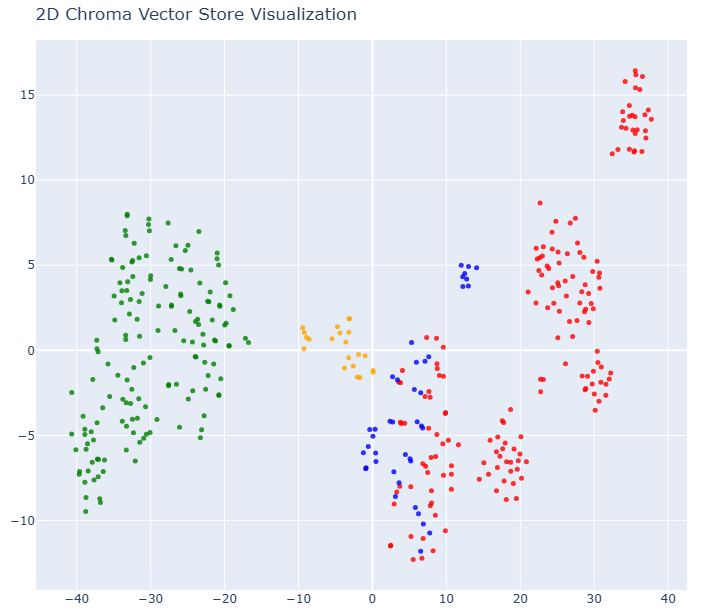

In [20]:
tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 2D scatter plot
fig = go.Figure(data=[go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(title='2D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x',yaxis_title='y'),
    width=800,
    height=600,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

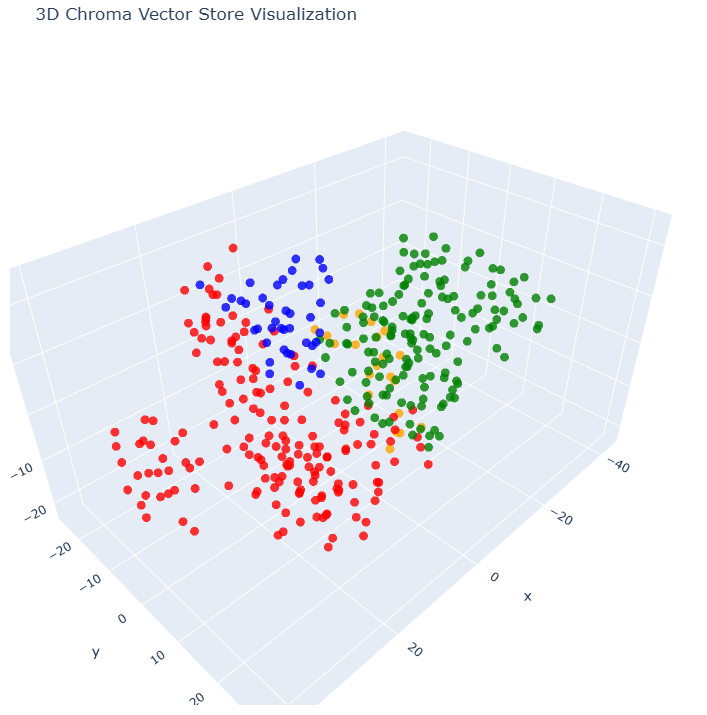

In [21]:
tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='3D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=900,
    height=700,
    margin=dict(r=10, b=10, l=10, t=40)
)

fig.show()

## And now - let's build an Advanced RAG!

We will use these techniques:

1. Reranking - reorder the rank results
2. Query re-writing

In [22]:
class RankOrder(BaseModel):
    order: list[int] = Field(
        description="The order of relevance of chunks, from most relevant to least relevant, by chunk id number"
    )

In [23]:
def rerank(question, chunks):
    system_prompt = """
You are a document re-ranker.
You are provided with a question and a list of relevant chunks of text from a query of a knowledge base.
The chunks are provided in the order they were retrieved; this should be approximately ordered by relevance, but you may be able to improve on that.
You must rank order the provided chunks by relevance to the question, with the most relevant chunk first.
Reply only with the list of ranked chunk ids, nothing else. Include all the chunk ids you are provided with, reranked.
"""
    user_prompt = f"The user has asked the following question:\n\n{question}\n\nOrder all the chunks of text by relevance to the question, from most relevant to least relevant. Include all the chunk ids you are provided with, reranked.\n\n"
    user_prompt += "Here are the chunks:\n\n"
    for index, chunk in enumerate(chunks):
        user_prompt += f"# CHUNK ID: {index + 1}:\n\n{chunk.page_content}\n\n"
    user_prompt += "Reply only with the list of ranked chunk ids, nothing else."
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    response = completion(model=MODEL, messages=messages, response_format=RankOrder)
    reply = response.choices[0].message.content
    order = RankOrder.model_validate_json(reply).order
    print(order)
    return [chunks[i - 1] for i in order]

In [24]:
RETRIEVAL_K = 10

def fetch_context_unranked(question):
    query = openai.embeddings.create(model=embedding_model, input=[question]).data[0].embedding
    results = collection.query(query_embeddings=[query], n_results=RETRIEVAL_K)
    chunks = []
    for result in zip(results["documents"][0], results["metadatas"][0]):
        chunks.append(Result(page_content=result[0], metadata=result[1]))
    return chunks

In [25]:
question = "Who won the IIOTY award?"
chunks = fetch_context_unranked(question)

In [26]:
for chunk in chunks:
    print(chunk.page_content[:15]+"...")

Career Progress...
Performance and...
Performance His...
Annual Performa...
Performance and...
Alex Chen's Per...
Career Progress...
Performance and...
Additional HR N...
Career Progress...


In [27]:
reranked = rerank(question, chunks)

[1, 8, 2, 3, 4, 5, 6, 7, 9, 10]


In [28]:
for chunk in reranked:
    print(chunk.page_content[:15]+"...")

Career Progress...
Performance and...
Performance and...
Performance His...
Annual Performa...
Performance and...
Alex Chen's Per...
Career Progress...
Additional HR N...
Career Progress...


In [29]:
question = "Who went to Manchester University?"
RETRIEVAL_K = 20
chunks = fetch_context_unranked(question)
for index, c in enumerate(chunks):
    if "manchester" in c.page_content.lower():
        print(index)

In [30]:
reranked = rerank(question, chunks)

[14, 1, 4, 7, 8, 9, 10, 11, 13, 12, 3, 2, 5, 6, 15, 16, 17, 18, 19, 20]


In [31]:
for index, c in enumerate(reranked):
    if "manchester" in c.page_content.lower():
        print(index)

In [32]:
reranked[0].page_content

'Insurellm Career Progression - Early Roles and Co-Founding\n\nAvery co-founded Insurellm in 2015 and previously worked as a Senior Product Manager and Business Analyst, gaining experience in insurance product development and market analysis.\n\n## Insurellm Career Progression\n- **2015 - Present**: Co-Founder & CEO  \n  Avery Lancaster co-founded Insurellm in 2015 and has since guided the company to its current position as a leading Insurance Tech provider. Avery is known for her innovative leadership strategies and risk management expertise that have catapulted the company into the mainstream insurance market.  \n\n- **2013 - 2015**: Senior Product Manager at Innovate Insurance Solutions  \n  Before launching Insurellm, Avery was a leading Senior Product Manager at Innovate Insurance Solutions, where she developed groundbreaking insurance products aimed at the tech sector.  \n\n- **2010 - 2013**: Business Analyst at Edge Analytics  \n  Prior to joining Innovate, Avery worked as a Bus

In [33]:
def fetch_context(question):
    chunks = fetch_context_unranked(question)
    return rerank(question, chunks)

In [34]:
SYSTEM_PROMPT = """
You are a knowledgeable, friendly assistant representing the company Insurellm.
You are chatting with a user about Insurellm.
Your answer will be evaluated for accuracy, relevance and completeness, so make sure it only answers the question and fully answers it.
If you don't know the answer, say so.
For context, here are specific extracts from the Knowledge Base that might be directly relevant to the user's question:
{context}

With this context, please answer the user's question. Be accurate, relevant and complete.
"""

In [35]:
# In the context, include the source of the chunk

def make_rag_messages(question, history, chunks):
    context = "\n\n".join(f"Extract from {chunk.metadata['source']}:\n{chunk.page_content}" for chunk in chunks)
    system_prompt = SYSTEM_PROMPT.format(context=context)
    return [{"role": "system", "content": system_prompt}] + history + [{"role": "user", "content": question}]

In [36]:
def rewrite_query(question, history=[]):
    """Rewrite the user's question to be a more specific question that is more likely to surface relevant content in the Knowledge Base."""
    message = f"""
You are in a conversation with a user, answering questions about the company Insurellm.
You are about to look up information in a Knowledge Base to answer the user's question.

This is the history of your conversation so far with the user:
{history}

And this is the user's current question:
{question}

Respond only with a single, refined question that you will use to search the Knowledge Base.
It should be a VERY short specific question most likely to surface content. Focus on the question details.
Don't mention the company name unless it's a general question about the company.
IMPORTANT: Respond ONLY with the knowledgebase query, nothing else.
"""
    response = completion(model=MODEL, messages=[{"role": "system", "content": message}])
    return response.choices[0].message.content

In [37]:
rewrite_query("Who won the IIOTY award?", [])

'Who received the IIOTY award?'

In [38]:
def answer_question(question: str, history: list[dict] = []) -> tuple[str, list]:
    """
    Answer a question using RAG and return the answer and the retrieved context
    """
    query = rewrite_query(question, history)
    print(query)
    chunks = fetch_context(query)
    messages = make_rag_messages(question, history, chunks)
    response = completion(model=MODEL, messages=messages)
    return response.choices[0].message.content, chunks

In [39]:
answer_question("Who won the IIOTY award?", [])

Who received the IIOTY award?
[1, 6, 14, 4, 8, 15, 3, 5, 9, 10, 12, 13, 16, 2, 7, 11, 17, 18, 19, 20]


('Maxine Thompson at Insurellm received the IIOTY (Insurellm Innovator of the Year) award in 2023.',
 [Result(page_content='Career Progression (Part 3)\n\nSince 2021, Maxine has been a Senior Data Engineer, leading projects, mentoring, and receiving notable awards.\n\n- **January 2021 - Present**: **Senior Data Engineer**  \n  * Maxine was promoted to Senior Data Engineer after successfully leading a pivotal project that improved data retrieval times by 30%. She now mentors junior engineers and is involved in strategic data initiatives, solidifying her position as a valued asset at Insurellm. She was recognized as Insurellm Innovator of the year in 2023, receiving the prestigious IIOTY 2023 award.', metadata={'type': 'employees', 'source': 'knowledge-base/employees/Maxine Thompson.md'}),
  Result(page_content='Additional HR Notes and Initiatives\n\nMaxine has engaged in training, received awards, and participated in mentorship and diversity initiatives, demonstrating her active role in

In [40]:
answer_question("Who went to Manchester University?", [])

Who attended Manchester University?
[14, 13, 17, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 18, 19, 20]


('The provided information does not indicate that anyone from Insurellm attended Manchester University.',
 [Result(page_content='Insurellm Career Progression - Early Roles and Co-Founding\n\nAvery co-founded Insurellm in 2015 and previously worked as a Senior Product Manager and Business Analyst, gaining experience in insurance product development and market analysis.\n\n## Insurellm Career Progression\n- **2015 - Present**: Co-Founder & CEO  \n  Avery Lancaster co-founded Insurellm in 2015 and has since guided the company to its current position as a leading Insurance Tech provider. Avery is known for her innovative leadership strategies and risk management expertise that have catapulted the company into the mainstream insurance market.  \n\n- **2013 - 2015**: Senior Product Manager at Innovate Insurance Solutions  \n  Before launching Insurellm, Avery was a leading Senior Product Manager at Innovate Insurance Solutions, where she developed groundbreaking insurance products aimed at t

In [41]:
answer_question("Who got promotion", [])

Who received recent promotions?
[1, 3, 6, 2, 4, 7, 8, 12, 10, 14, 15, 16, 20, 9, 13, 19, 18, 17]


('Based on the available information, several employees at Insurellm received promotions:\n\n- **Jordan Blake** was promoted from Entry-Level SDR to Junior SDR in February 2022.\n- **Oliver Spencer** was promoted to Backend Developer II in July 2019 and later transitioned to a broader backend software engineering role in June 2021.\n- **Alex Chen** was promoted from Junior Backend Developer to Backend Software Engineer in October 2021, and then to Senior Backend Software Engineer in March 2023.\n- **Maxine Thompson** has been a Senior Data Engineer since January 2021, with no specific promotion mentioned, but she has taken on leadership and mentoring roles.\n- **Emily Carter** shifted roles from Sales Coordinator to Account Executive, which typically involves a promotion, by 2021.\n- **Rachel Martinez** advanced from Associate Product Manager to Product Manager in March 2019.\n\nThese are the promotions explicitly noted in the provided data. If you need information on a specific indivi